# Prototype ENM Hessian matrix construction

Resources:

https://github.com/ando-lab/mdx-lib/blob/master/%2Bnm/ElasticNetwork_v2.m

Overview:

If we are computing the Hessian in cartesian coordinates, the key steps are:
- Create the ENM (lists of contacts)
- For each contact, compute the unit vector connecting the two nodes
- Construct the "edge matrix" (E), which maps from cartesian to edge space
- For crystalline elastic networks, consider unit cell neighbors separately
    - (possible extension: treat symmetry images in a similar manner to unit cell neighbors)


If we are computing the Hessian in TL coordinates, we additionally need:
- Definitions of the rigid groups
- A center of mass for each rigid group
- A projection matrix P that goes from cartesian space to TL coordinates relative to the center of mass
- A mass tensor in TL coordinates for each rigid group, computed from the P matrix
- Compute matrix that maps from edge space to TL coordinates: E := P @ E

Where to start? Let's do some exercises.

**Exercise 1**. Assign rigid groups. Use Mac1 P43 + ADPr [7TX0](https://www.rcsb.org/structure/7TX0), with two copies in the ASU. Group atoms by chain ID.

**Exersise 2**. Construct the contacts list for the ASU. Keep only contacts between groups (or with other ASUs).

**Exercise 3**. Expand to P1 and add node positions. Visualize the unit cell.

**Exercise 4**. Projection to TL coordinates. Compute mass matrix for each rigid group. 

**Exercise 5**. Incidence matrix for the ASU. Internal springs only, no symmetry ops -- i.e. between the two chains of Mac1.

**Exercise 6**. Hessian matrix for the unit cell. Use TL coordinate projection of P1 cell, apply periodic boundary conditions.

## Ex 1. Assign rigid groups

In [1]:
# !cd test_data && curl -O https://files.rcsb.org/download/7TX0.cif

import gemmi

coordinate_file = 'test_data/7TX0.cif'

st = gemmi.read_structure(coordinate_file)
st.setup_entities()  # supposed to be good practice

groups = [
    gemmi.Selection('//A;polymer'),
    gemmi.Selection('//B;polymer'),
]

tls_groups = []

# calculate the group center of mass, store as TLS group origin
for group_id, selection in enumerate(groups):
    model = selection.copy_model_selection(st[0])
    com = model.calculate_center_of_mass()
    g = gemmi.TlsGroup()
    g.id = f"TLS{group_id}"  # why is this a string? why can't I access num_id property?
    g.origin = com
    tls_groups.append(g)

st.meta.refinement[0].tls_groups = tls_groups

for group_id, selection in enumerate(groups):
    for model in selection.models(st):
        for chain in selection.chains(model):
            for residue in selection.residues(chain):
                for atom in selection.atoms(residue):
                    atom.tls_group_id = group_id

# question... does the tls_group_id index into the list of TLS groups? or does there need to be some other mapping?


## Ex 2. Construct the contacts list

In [2]:
from goodvibes import enm

enm._pack_unit_cell(st, inplace=True)

df = enm._find_contacts(
   st,
   distance_cutoff=4.0,
   include_h=False,
)

def address_from_cra_string(cra):
    chain, residue, atom = cra.split('/')
    resname, seqid = residue.split()
    if '.' in atom:
        atom, altloc = atom.split('.')
    else:
        altloc = '\x00'
    addr =  gemmi.AtomAddress(chain, gemmi.SeqId(seqid), resname, atom, altloc)
    return addr

df['group_id1'] = -1
df['group_id2'] = -1

# add group ID columns to dataframe
for row in df.itertuples():
    cra1 = st[0].find_cra(address_from_cra_string(row.cra1))
    cra2 = st[0].find_cra(address_from_cra_string(row.cra2))
    df.at[row.Index, 'group_id1'] = cra1.atom.tls_group_id
    df.at[row.Index, 'group_id2'] = cra2.atom.tls_group_id

df['external'] = False

# add a column that indicates whether the contact is external (between different groups)
for row in df.itertuples():
    if row.group_id1 == -1 or row.group_id2 == -1:
        df.at[row.Index, 'external'] = False
    elif (row.sym_idx1 == row.sym_idx2) and (row.pbc_shift1 == row.pbc_shift2):
        # same ASU, check if the two residues have the same flag (i.e. belong to the same rigid group)
        df.at[row.Index, 'external'] = (row.group_id1 != row.group_id2)
    else:
        # different ASU, any group flag (not null)
        df.at[row.Index, 'external'] = True

# create a new dataframe that contains only the external contacts, dropping the 'external' column, reset index.
external_df = df[df['external']].drop(columns=['external']).reset_index(drop=True)
external_df

,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2
0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
3,A/TYR 9/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
4,A/TYR 9/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0
...,...,...,...,...,...,...,...,...
612,B/LEU 169/CD1,B/ASP 22/OD1,0,1,"(0, 0, 0)","(-1, 0, -1)",1,1
613,B/LEU 169/CD1,B/ASP 22/OD2,0,1,"(0, 0, 0)","(-1, 0, -1)",1,1
614,B/LEU 169/CD2,B/ILE 23/CG2,0,1,"(0, 0, 0)","(-1, 0, -1)",1,1
615,B/LEU 169/CD2,B/ALA 52/CB,0,1,"(0, 0, 0)","(-1, 0, -1)",1,1


In [3]:
# group by columns sym_idx1, sym_idx2, pbc_shift1, pbc_shift2, group_id1, group_id2 and count the number of contacts
grouped_df = external_df.groupby(['sym_idx1', 'sym_idx2', 'pbc_shift1', 'pbc_shift2', 'group_id1', 'group_id2']).size()
grouped_df

sym_idx1  sym_idx2  pbc_shift1  pbc_shift2   group_id1  group_id2
0         0         (0, 0, 0)   (0, 0, -1)   0          0             9
                                             1          1            21
                                (0, 0, 0)    0          1            83
                                (0, 0, 1)    0          0             9
                                             1          1            21
          1         (0, 0, 0)   (-1, 0, -1)  1          1            70
                                (0, 0, -1)   0          0            85
          2         (0, 0, 0)   (0, -1, -1)  0          1            18
                                             1          0            64
                                (0, -1, 0)   0          1            64
                                             1          0            18
          3         (0, 0, 0)   (0, -1, 0)   1          1            70
                                (0, 0, 0)    0          0            8

## Ex 3. Expand to P1

In [4]:
import pandas as pd

external_df_expanded = enm._symmetry_expand(external_df, st.cell.images)

def transform_position(st, sym_idx, pbc_shift, pos):
    if sym_idx == 0:
        image_transform = gemmi.Transform()
    else:
        image_transform = st.cell.images[sym_idx - 1]
    pbc_transform = gemmi.Transform(gemmi.Mat33(), gemmi.Vec3(*pbc_shift))
    t = pbc_transform @ image_transform
    return st.cell.orthogonalize(gemmi.Fractional(t.apply(st.cell.fractionalize(pos))))

external_df_expanded['r1'] = pd.Series([None] * len(external_df_expanded), dtype=object)
external_df_expanded['r2'] = pd.Series([None] * len(external_df_expanded), dtype=object)

for row in external_df_expanded.itertuples():
    cra1 = st[0].find_cra(address_from_cra_string(row.cra1))
    cra2 = st[0].find_cra(address_from_cra_string(row.cra2))
    pos1 = transform_position(st, row.sym_idx1, row.pbc_shift1, cra1.atom.pos)
    pos2 = transform_position(st, row.sym_idx2, row.pbc_shift2, cra2.atom.pos)
    external_df_expanded.at[row.Index, 'r1'] = (pos1.x, pos1.y, pos1.z)
    external_df_expanded.at[row.Index, 'r2'] = (pos2.x, pos2.y, pos2.z)

external_df_expanded

,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2,r1,r2
0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.19777, 35.47873, 15.606150000000001)","(33.5479, 38.297419999999995, 15.76611)"
1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(34.09091, 38.94922, 14.69258)"
2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(33.5479, 38.297419999999995, 15.76611)"
3,A/TYR 9/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(33.53765, 35.06444, 13.83823)","(33.5479, 38.297419999999995, 15.76611)"
4,A/TYR 9/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(32.68961, 35.29065, 14.70957)","(34.09091, 38.94922, 14.69258)"
...,...,...,...,...,...,...,...,...,...,...
2208,B/LEU 169/CD1,B/ASP 22/OD1,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(15.612220000000002, 79.41917, -4.556659999999...","(17.4578, 79.14677999999999, -7.70419)"
2209,B/LEU 169/CD1,B/ASP 22/OD2,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(15.612220000000002, 79.41917, -4.556659999999...","(15.84539, 77.71637999999999, -7.72701)"
2210,B/LEU 169/CD2,B/ILE 23/CG2,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(17.03124, 81.20943, -3.626659999999998)","(19.34131, 83.05068999999999, -5.65706)"
2211,B/LEU 169/CD2,B/ALA 52/CB,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(17.03124, 81.20943, -3.626659999999998)","(18.87069, 78.58950999999999, -1.90476)"


/var/folders/bs/hkvq730j1q7bscf60_pkcmq00000gn/T/ipykernel_57706/750280449.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(unique_pbc_shifts))


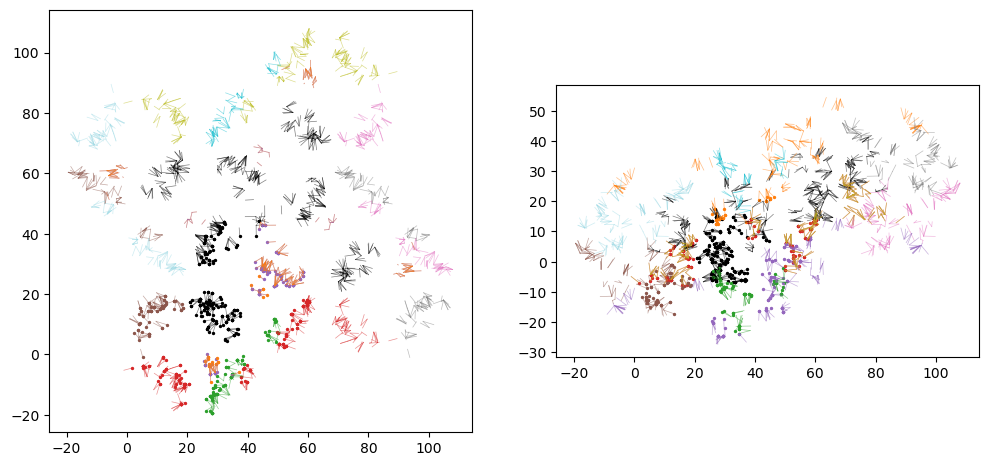

In [5]:
# plot the external contacts as lines in 2d projections.
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# assign unique values of pbc_shift2 to colors
unique_pbc_shifts = external_df_expanded['pbc_shift2'].unique()
colors = plt.cm.get_cmap('tab20', len(unique_pbc_shifts))

for row in external_df_expanded.itertuples():
    # if row.sym_idx1 != 0:
    #     continue  # only plot contacts from the reference ASU
    x1, y1, z1 = row.r1
    x2, y2, z2 = row.r2
    # color by pbc_shift1 and pbc_shift2 not 0,0,0
    color = colors(list(unique_pbc_shifts).index(row.pbc_shift2)) if row.pbc_shift2 != (0, 0, 0) else 'k'

    ax1.plot([x1, x2], [y1, y2], color=color, alpha=0.5, linewidth=.5)
    ax2.plot([x1, x2], [z1, z2], color=color, alpha=0.5, linewidth=.5)
    if row.sym_idx1 == 0:
        ax1.scatter(x1, y1, color=color, s=2)
        ax2.scatter(x1, z1, color=color, s=2)
    if (row.pbc_shift2 == (0, 0, 0)) and (row.sym_idx2 == 0):
        ax1.scatter(x2, y2, color=color, s=2)
        ax2.scatter(x2, z2, color=color, s=2)
# equal aspect
ax1.set_aspect('equal', 'box')
ax2.set_aspect('equal', 'box')

## Ex 4. Projection to TL coordinates

In [6]:
# let's grab a position in chain A.
import numpy as np

# get first atom of groups[0] selection:
cra = groups[0].first_in_model(st[0])
tls_ori = st.meta.refinement[0].tls_groups[cra.atom.tls_group_id].origin
dr = cra.atom.pos - tls_ori
A = np.array([[1, 0, 0, 0, dr.z, -dr.y], [0, 1, 0, -dr.z, 0, dr.x], [0, 0, 1, dr.y, -dr.x, 0]])
A.shape

(3, 6)

In [7]:
group_mass_tensors = [np.zeros((6, 6)) for _ in range(len(groups))]

for group_id, selection in enumerate(groups):
    tls_ori = st.meta.refinement[0].tls_groups[group_id].origin
    for model in selection.models(st):
        for chain in selection.chains(model):
            for residue in selection.residues(chain):
                for atom in selection.atoms(residue):
                    dr = atom.pos - tls_ori
                    A = np.array([[1, 0, 0, 0, dr.z, -dr.y], [0, 1, 0, -dr.z, 0, dr.x], [0, 0, 1, dr.y, -dr.x, 0]])
                    group_mass_tensors[group_id] += atom.element.weight * atom.occ * A.T @ A

group_mass_tensors

# this looks reasonable, but is it actually correct? I should try to replicate what is done in MATLAB.

[array([[ 1.77240518e+04,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  2.66857647e-11, -8.89244234e-12],
        [ 0.00000000e+00,  1.77240518e+04,  0.00000000e+00,
         -2.66857647e-11,  0.00000000e+00,  3.06446424e-10],
        [ 0.00000000e+00,  0.00000000e+00,  1.77240518e+04,
          8.89244234e-12, -3.06446424e-10,  0.00000000e+00],
        [ 0.00000000e+00, -2.66857647e-11,  8.89244234e-12,
          2.67337700e+06,  5.01535585e+05, -8.72009934e+04],
        [ 2.66857647e-11,  0.00000000e+00, -3.06446424e-10,
          5.01535585e+05,  2.41592405e+06, -9.64788563e+04],
        [-8.89244234e-12,  3.06446424e-10,  0.00000000e+00,
         -8.72009934e+04, -9.64788563e+04,  2.67731960e+06]]),
 array([[ 1.81560151e+04,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  2.88764568e-11, -1.09469767e-10],
        [ 0.00000000e+00,  1.81560151e+04,  0.00000000e+00,
         -2.88764568e-11,  0.00000000e+00, -1.12096998e-10],
        [ 0.00000000e+00,  0.0

In [8]:
# this is to double-check that the sparse projection matrix method from MATLAB gives the same result as above.

from scipy import sparse

# lay out P matrix with 2*6 columns (one for each group) and N*3 rows (one for each atom)

atom_id = 0
row_indices = []
col_indices = []
values = []
for group_id, selection in enumerate(groups):
    tls_ori = st.meta.refinement[0].tls_groups[group_id].origin
    for model in selection.models(st):
        for chain in selection.chains(model):
            for residue in selection.residues(chain):
                for atom in selection.atoms(residue):
                    dr = atom.pos - tls_ori
                    row_start = atom_id*3
                    col_start = group_id*6
                    sqrt_mass = np.sqrt(atom.element.weight * atom.occ)
                    row_indices.extend([n + row_start for n in [0,1,2,0,0,1,1,2,2]])
                    col_indices.extend([n + col_start for n in [0,1,2,4,5,3,5,3,4]])
                    values.extend([v*sqrt_mass for v in [1, 1, 1, dr.z, -dr.y, -dr.z, dr.x, dr.y, -dr.x]])
                    atom_id += 1
num_atoms = atom_id
P = sparse.csr_array((values, (row_indices, col_indices)), shape=(num_atoms*3, len(groups)*6))
PP = P.T @ P
PP = PP.toarray()
print(np.allclose(PP[:6,:6],group_mass_tensors[0]))
print(np.allclose(PP[6:,6:],group_mass_tensors[1]))

True
True


## Ex 5. Incidence matrix for the ASU

In [9]:
# have a look at the inter-group springs within the ASU (no symmetry info required)
asu_df = external_df[(external_df['sym_idx2']==0) & (external_df['pbc_shift2']==(0,0,0))].copy()

# create a mapping between nodes (identified by cra string) and indices in an array
cra_index_map = {}

for row in asu_df.itertuples():
    if row.cra1 not in cra_index_map:
        cra_index_map[row.cra1] = len(cra_index_map)
    if row.cra2 not in cra_index_map:
        cra_index_map[row.cra2] = len(cra_index_map)

# compute the unit vector along each edge and node position relative to tls matrix ori
asu_df['dn'] = pd.Series([None] * len(asu_df), dtype=object)
for row in asu_df.itertuples():
    cra1 = st[0].find_cra(address_from_cra_string(row.cra1))
    cra2 = st[0].find_cra(address_from_cra_string(row.cra2))
    dn = (cra2.atom.pos - cra1.atom.pos).normalized()
    asu_df.at[row.Index, 'dn'] = (dn.x, dn.y, dn.z)

row_indices = []
col_indices = []
values = []
for edge_index, row in enumerate(asu_df.itertuples()):
    dn = row.dn
    col_index_start = 3*cra_index_map[row.cra1]
    row_index_start = 3*edge_index
    row_indices.extend([row_index_start + n for n in range(3)])
    col_indices.extend([col_index_start + n for n in range(3)])
    values.extend([-1*v for v in dn])
    col_index_start = 3*cra_index_map[row.cra2]
    row_indices.extend([row_index_start + n for n in range(3)])
    col_indices.extend([col_index_start + n for n in range(3)])
    values.extend(list(dn))

E = sparse.csr_array((values, (row_indices, col_indices)), shape=(3*len(asu_df), 3*len(cra_index_map)))
E

<Compressed Sparse Row sparse array of dtype 'float64'
	with 498 stored elements and shape (249, 210)>

In [10]:
# compute TL projection matrix for the nodes

row_indices = []
col_indices = []
values = []
tls_groups = st.meta.refinement[0].tls_groups
for cra_string, node_index in cra_index_map.items():
    cra = st[0].find_cra(address_from_cra_string(cra_string))
    group_id = cra.atom.tls_group_id
    row_start = node_index*3
    col_start = group_id*6
    dr = cra.atom.pos - tls_groups[group_id].origin
    row_indices.extend([n + row_start for n in [0,1,2,0,0,1,1,2,2]])
    col_indices.extend([n + col_start for n in [0,1,2,4,5,3,5,3,4]])
    values.extend([1, 1, 1, dr.z, -dr.y, -dr.z, dr.x, dr.y, -dr.x])

P = sparse.csr_array((values, (row_indices, col_indices)), shape=(len(cra_index_map)*3, len(tls_groups)*6))
P

<Compressed Sparse Row sparse array of dtype 'float64'
	with 630 stored elements and shape (210, 12)>

In [11]:
EP = E @ P
EP

<Compressed Sparse Row sparse array of dtype 'float64'
	with 1494 stored elements and shape (249, 12)>

In [12]:
K = (EP.T @ EP)
K

<Compressed Sparse Column sparse array of dtype 'float64'
	with 96 stored elements and shape (12, 12)>

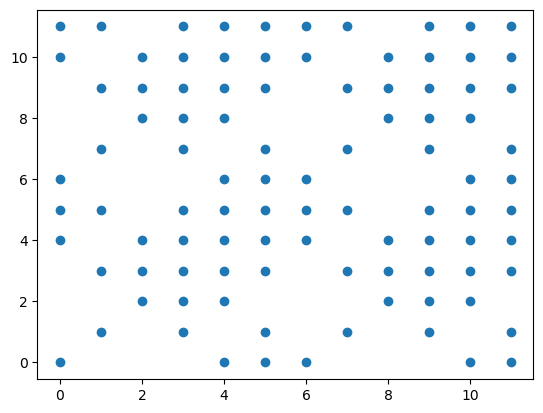

In [13]:
c = K.tocoo()
plt.scatter(c.col,c.row)

## Ex 6. Hessian matrix for the unit cell.

In [14]:
external_df_expanded

,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2,r1,r2
0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.19777, 35.47873, 15.606150000000001)","(33.5479, 38.297419999999995, 15.76611)"
1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(34.09091, 38.94922, 14.69258)"
2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(33.5479, 38.297419999999995, 15.76611)"
3,A/TYR 9/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(33.53765, 35.06444, 13.83823)","(33.5479, 38.297419999999995, 15.76611)"
4,A/TYR 9/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(32.68961, 35.29065, 14.70957)","(34.09091, 38.94922, 14.69258)"
...,...,...,...,...,...,...,...,...,...,...
2208,B/LEU 169/CD1,B/ASP 22/OD1,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(15.612220000000002, 79.41917, -4.556659999999...","(17.4578, 79.14677999999999, -7.70419)"
2209,B/LEU 169/CD1,B/ASP 22/OD2,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(15.612220000000002, 79.41917, -4.556659999999...","(15.84539, 77.71637999999999, -7.72701)"
2210,B/LEU 169/CD2,B/ILE 23/CG2,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(17.03124, 81.20943, -3.626659999999998)","(19.34131, 83.05068999999999, -5.65706)"
2211,B/LEU 169/CD2,B/ALA 52/CB,3,0,"(0, 0, 0)","(0, 1, 0)",1,1,"(17.03124, 81.20943, -3.626659999999998)","(18.87069, 78.58950999999999, -1.90476)"


In [15]:
# For computing this, first calculate the normal vector in ASU reference frame: R^T (r2-r1)/|r2-r1| and make sure that
# different ASU copies agree.

external_df_expanded['n1'] = pd.Series([None] * len(external_df_expanded), dtype=object)
external_df_expanded['n2'] = pd.Series([None] * len(external_df_expanded), dtype=object)

for row in external_df_expanded.itertuples():
    n = gemmi.Vec3(*row.r2) - gemmi.Vec3(*row.r1)
    n /= n.length()
    if row.sym_idx1 == 0:
        R1 = gemmi.Mat33()
    else:
        R1 = st.cell.images[row.sym_idx1 - 1].mat
    if row.sym_idx2 == 0:
        R2 = gemmi.Mat33()
    else:
        R2 = st.cell.images[row.sym_idx2 - 1].mat
    n1 = R1.transpose() @ n
    n2 = R2.transpose() @ n
    external_df_expanded.at[row.Index, 'n1'] = (n1.x, n1.y, n1.z)
    external_df_expanded.at[row.Index, 'n2'] = (n2.x, n2.y, n2.z)

In [16]:
external_df_expanded.set_index(['cra1','cra2']).sort_index()

sym_idx1  sym_idx2 pbc_shift1  pbc_shift2  \
cra1         cra2                                                        
A/ALA 129/O  A/SER 166/OG.A         0         1  (0, 0, 0)  (0, 0, -1)   
             A/SER 166/OG.A         1         2  (0, 0, 0)   (0, 0, 0)   
             A/SER 166/OG.A         2         3  (0, 0, 0)   (0, 0, 0)   
A/ALA 52/N   A/LYS 11/CD            0         1  (0, 0, 0)  (0, 0, -1)   
             A/LYS 11/CD            1         2  (0, 0, 0)   (0, 0, 0)   
...                               ...       ...        ...         ...   
B/VAL 49/CG2 B/LEU 169/C            3         2  (0, 0, 0)  (-1, 0, 0)   
             B/LEU 169/O            0         3  (0, 0, 0)  (0, -1, 0)   
             B/LEU 169/O            1         0  (0, 0, 0)   (1, 0, 1)   
             B/LEU 169/O            2         1  (0, 0, 0)   (0, 1, 0)   
             B/LEU 169/O            3         2  (0, 0, 0)  (-1, 0, 0)   

                             group_id1  group_id2  \
cra1         cra2                                   
A/ALA 129/O  A/SER 166/OG.A          0          0   
             A/SER 166/OG.A          0          0   
             A/SER 166/OG.A          0          0   
A/ALA 52/N   A/LYS 11/CD             0          0   
             A/LYS 11/CD             0          0   
...                                ...        ...   
B/VAL 49/CG2 B/LEU 169/C             1          1   
             B/LEU 169/O             1          1   
             B/LEU 169/O             1          1   
             B/LEU 169/O             1          1   
             B/LEU 169/O             1          1   

                                                                            r1  \
cra1         cra2                                                                
A/ALA 129/O  A/SER 166/OG.A                     (42.37165, 30.65365, -4.23508)   
             A/SER 166/OG.A           (57.79735, 42.37165, 25.632170000000002)   
             A/SER 166/OG.A  (46.07934999999999, 57.79735, 15.676420000000002)   
A/ALA 52/N   A/LYS 11/CD                            (51.85454, 24.05065, 4.92)   
             A/LYS 11/CD               (64.40034999999999, 51.85454, 34.78725)   
...                                                                        ...   
B/VAL 49/CG2 B/LEU 169/C                (-3.63668, 70.72945999999999, 8.51282)   
             B/LEU 169/O                        (17.72154, -3.63668, -1.44293)   
             B/LEU 169/O               (92.08767999999999, 17.72154, 28.42432)   
             B/LEU 169/O      (70.72945999999999, 92.08767999999999, 18.46857)   
             B/LEU 169/O                (-3.63668, 70.72945999999999, 8.51282)   

                                                                            r2  \
cra1         cra2                                                                
A/ALA 129/O  A/SER 166/OG.A            (44.69086999999999, 32.04797, -6.36586)   
             A/SER 166/OG.A  (56.40302999999999, 44.69086999999999, 23.5013...   
             A/SER 166/OG.A            (43.76013, 56.40302999999999, 13.54564)   
A/ALA 52/N   A/LYS 11/CD     (55.072299999999984, 25.7504, 3.5411099999999984)   
             A/LYS 11/CD     (62.700599999999994, 55.072299999999984, 33.40...   
...                                                                        ...   
B/VAL 49/CG2 B/LEU 169/C     (-4.70684, 73.99974999999999, 7.0950299999999995)   
             B/LEU 169/O     (15.284240000000002, -4.38406, -3.707000000000...   
             B/LEU 169/O              (92.83506, 15.284240000000002, 26.16025)   
             B/LEU 169/O                         (73.16676, 92.83506, 16.2045)   
             B/LEU 169/O               (-4.38406, 73.16676, 6.248749999999999)   

                                                                            n1  \
cra1         cra2                                                                
A/ALA 129/O  A/SER 166/OG.A  (0.6733521428336533, 0.4048207413681431, -0.61...

In [17]:
# compute Hessian matrix?
#
# How to handle PBC? I think with current expanded model, the springs between unit cells will be double-counted.
# Can detect this, I think, by dropping the pbc_shift columns and finding unique edges.

external_df_expanded_pbc = external_df_expanded.copy()

for row in external_df_expanded.itertuples():
    if (row.cra1, row.sym_idx1) > (row.cra2, row.sym_idx2):
        external_df_expanded_pbc.at[row.Index, 'cra1'] = row.cra2
        external_df_expanded_pbc.at[row.Index, 'sym_idx1'] = row.sym_idx2
        external_df_expanded_pbc.at[row.Index, 'pbc_shift1'] = row.pbc_shift2
        external_df_expanded_pbc.at[row.Index, 'group_id1'] = row.group_id2
        external_df_expanded_pbc.at[row.Index, 'r1'] = row.r2
        external_df_expanded_pbc.at[row.Index, 'n1'] = row.n2
        external_df_expanded_pbc.at[row.Index, 'cra2'] = row.cra1
        external_df_expanded_pbc.at[row.Index, 'sym_idx2'] = row.sym_idx1
        external_df_expanded_pbc.at[row.Index, 'pbc_shift2'] = row.pbc_shift1
        external_df_expanded_pbc.at[row.Index, 'group_id2'] = row.group_id1
        external_df_expanded_pbc.at[row.Index, 'r2'] = row.r1
        external_df_expanded_pbc.at[row.Index, 'n2'] = row.n1

external_df_expanded_pbc.drop_duplicates(subset=['cra1','cra2','sym_idx1','sym_idx2'],inplace=True)
external_df_expanded_pbc

,cra1,cra2,sym_idx1,sym_idx2,pbc_shift1,pbc_shift2,group_id1,group_id2,r1,r2,n1,n2
0,A/GLY 8/C,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.19777, 35.47873, 15.606150000000001)","(33.5479, 38.297419999999995, 15.76611)","(-0.6843666236758299, 0.7279667902534173, 0.04...","(-0.7279667902534173, -0.6843666236758299, 0.0..."
1,A/GLY 8/O,A/PHE 156/CE2,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(34.09091, 38.94922, 14.69258)","(-0.6724555449669695, 0.7401304577269437, 0.00...","(-0.7401304577269437, -0.6724555449669695, 0.0..."
2,A/GLY 8/O,A/PHE 156/CZ,0,3,"(0, 0, 0)","(0, 0, 0)",0,0,"(36.59681, 36.19113, 14.68052)","(33.5479, 38.297419999999995, 15.76611)","(-0.7895759269938094, 0.5454657170161752, 0.28...","(-0.5454657170161752, -0.7895759269938094, 0.2..."
3,A/PHE 156/CZ,A/TYR 9/C,3,0,"(0, 0, 0)","(0, 0, 0)",0,0,"(33.5479, 38.297419999999995, 15.76611)","(33.53765, 35.06444, 13.83823)","(-0.8588822583114761, 0.0027230428730434316, 0...","(0.0027230428730434316, 0.8588822583114761, 0...."
4,A/PHE 156/CE2,A/TYR 9/O,3,0,"(0, 0, 0)","(0, 0, 0)",0,0,"(34.09091, 38.94922, 14.69258)","(32.68961, 35.29065, 14.70957)","(-0.933835559897385, 0.3576762970461698, -0.00...","(0.3576762970461698, 0.933835559897385, -0.004..."
...,...,...,...,...,...,...,...,...,...,...,...,...
1978,B/ASN 4/O,B/TYR 42/OH.B,3,3,"(0, 0, 0)","(0, 0, -1)",1,1,"(0.10113000000000001, 61.87219999999999, -8.78...","(-0.9083000000000001, 61.58114, -12.4373400000...","(0.07658456551600085, -0.26560419833992366, -0...","(0.07658456551600085, -0.26560419833992366, -0..."
1979,B/SER 5/CA.B,B/TYR 42/OH.B,3,3,"(0, 0, 0)","(0, 0, -1)",1,1,"(-2.25059, 62.814809999999994, -9.76083)","(-0.9083000000000001, 61.58114, -12.4373400000...","(0.38094763875995763, 0.4144886444763226, -0.8...","(0.38094763875995763, 0.4144886444763226, -0.8..."
1980,B/SER 5/CB.B,B/TYR 42/CE2.B,3,3,"(0, 0, 0)","(0, 0, -1)",1,1,"(-3.511, 62.45516, -10.531149999999998)","(-2.07505, 62.62223, -14.22047)","(-0.04216339401839544, 0.36239016963377046, -0...","(-0.04216339401839544, 0.36239016963377046, -0..."
1981,B/SER 5/CB.B,B/TYR 42/CZ.B,3,3,"(0, 0, 0)","(0, 0, -1)",1,1,"(-3.511, 62.45516, -10.531149999999998)","(-1.64307, 61.47500999999999, -13.60131)","(0.2631264288238382, 0.5014556447410168, -0.82...","(0.2631264288238382, 0.5014556447410168, -0.82..."


In [23]:
# number of groups in the unit cell
tls_groups = st.meta.refinement[0].tls_groups
ngroups = (1 + len(st.cell.images))*len(tls_groups)
nedges = len(external_df_expanded_pbc)

row_indices = []
col_indices = []
values = []

for edge_index, row in enumerate(external_df_expanded_pbc.itertuples()):
    row_start = edge_index*3
    col_start1 = row.sym_idx1*6 + len(tls_groups)*row.sym_idx1
    col_start2 = row.sym_idx2*6 + len(tls_groups)*row.sym_idx2
    dr1 = gemmi.Position(*row.r1) - tls_groups[row.group_id1].origin
    dr2 = gemmi.Position(*row.r2) - tls_groups[row.group_id2].origin
    row_indices.extend([n + row_start for n in [0,1,2,0,0,1,1,2,2]])
    col_indices.extend([n + col_start1 for n in [0,1,2,4,5,3,5,3,4]])
    values.extend([-1*v for v in [1, 1, 1, dr1.z, -dr1.y, -dr1.z, dr1.x, dr1.y, -dr1.x]])
    row_indices.extend([n + row_start for n in [0,1,2,0,0,1,1,2,2]])
    col_indices.extend([n + col_start2 for n in [0,1,2,4,5,3,5,3,4]])
    values.extend([1, 1, 1, dr2.z, -dr2.y, -dr2.z, dr2.x, dr2.y, -dr2.x])

P = sparse.csr_array((values, (row_indices, col_indices)), shape=(nedges*3, ngroups*6))
P


<Compressed Sparse Row sparse array of dtype 'float64'
	with 21132 stored elements and shape (4200, 48)>

In [21]:
gemmi.Position(*row.r1)

<gemmi.Position(36.1978, 35.4787, 15.6062)>